In [63]:
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from collections import Counter
import matplotlib.pyplot as plt
import random
from qiskit import QuantumCircuit
from qiskit.circuit import QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit_algorithms import EstimationProblem, AmplitudeEstimation
import pandas as pd
from tqdm import tqdm
from statistics import mode

plt.style.use('dark_background')

plt.rcParams.update({
    'figure.facecolor':   '#282c34',  
    'axes.facecolor':     '#1e1e1e',    
    'grid.color':         '#444444',

    'figure.figsize': (10, 6),
    'figure.dpi': 150
})    

In [11]:
# --- Passo 1: Definição dos Parâmetros ---
# Parâmetros do nosso QkNN
M = 512  # Número de imagens de treino
N = 16   # Número de características (dimensão após PCA)

# Parâmetros de qubits correspondentes (para referência)
m = 9    # Qubits para endereçar as imagens (2^9 = 512)
n = 4    # Qubits para endereçar as características (2^4 = 16)

print(f"Configuração do Algoritmo:")
print(f"M = {M} (m = {m}) imagens de treino")
print(f"N = {N} (n = {n}) características por imagem")
print("-" * 30)

Configuração do Algoritmo:
M = 512 (m = 9) imagens de treino
N = 16 (n = 4) características por imagem
------------------------------


In [19]:
# --- Carregamento e Divisão Primária ---
print("1. Carregando e dividindo o dataset MNIST...")
try:
    X_all, y_all = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False, parser='auto')
    X_all = X_all / 255.0
    y_all = y_all.astype(int) # Garantir que os rótulos são inteiros

    # Dividir em um pool de treino (60k) e um conjunto de teste (10k)
    X_train_pool, X_test_set, y_train_pool, y_test_set = train_test_split(
        X_all, y_all,
        test_size=10000,
        random_state=42,
        stratify=y_all
    )
    print(f"Dados divididos: {len(X_train_pool)} no pool de treino, {len(X_test_set)} no conjunto de teste.")

except Exception as e:
    print(f"ERRO: Falha ao carregar o dataset. {e}")
    # Se der erro, o resto do notebook não funcionará
    # exit() # Em um notebook, podemos apenas parar a execução aqui.

1. Carregando e dividindo o dataset MNIST...
Dados divididos: 60000 no pool de treino, 10000 no conjunto de teste.


In [20]:
# --- Amostragem do Conjunto de Treino Fixo ---
print(f"\n2. Amostrando M={M} imagens do pool de treino...")

# Amostra estratificada do pool de treino
X_train_M, _, y_train_M, _ = train_test_split(
    X_train_pool, y_train_pool,
    train_size=M,
    random_state=42,
    stratify=y_train_pool
)

# y_train_M contém os rótulos corretos para as nossas M imagens de treino.
# Vamos guardar esta variável para a etapa final de votação majoritária.
print(f"Conjunto de treino de {len(X_train_M)} imagens criado.")
print(f"Distribuição de classes: {sorted(Counter(y_train_M).items())}")


2. Amostrando M=512 imagens do pool de treino...
Conjunto de treino de 512 imagens criado.
Distribuição de classes: [(0, 51), (1, 58), (2, 51), (3, 52), (4, 50), (5, 46), (6, 50), (7, 53), (8, 50), (9, 51)]



3. Selecionando uma imagem aleatória do conjunto de teste...
Imagem de teste de índice 1824 selecionada.
Seu rótulo verdadeiro (que o algoritmo tentará descobrir) é: 7


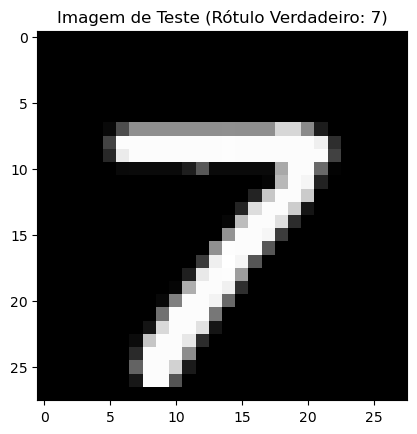

In [21]:
# --- Seleção da Imagem de Teste ---
print("\n3. Selecionando uma imagem aleatória do conjunto de teste...")

# Escolhe um índice aleatório do conjunto de teste
random.seed(42) # Para sempre pegarmos a mesma imagem "aleatória"
test_idx = random.randint(0, len(X_test_set)-1)

# Pega a imagem de teste (pixels) e seu rótulo verdadeiro
X_test_image_pixels = X_test_set[test_idx]
true_label = y_test_set[test_idx]

print(f"Imagem de teste de índice {test_idx} selecionada.")
print(f"Seu rótulo verdadeiro (que o algoritmo tentará descobrir) é: {true_label}")

# Visualizar
plt.imshow(X_test_image_pixels.reshape(28, 28), cmap='gray')
plt.title(f"Imagem de Teste (Rótulo Verdadeiro: {true_label})")
plt.show()

In [25]:
# --- Processamento de Features (Pré-processamento) ---
from sklearn.preprocessing import MinMaxScaler

print("\n4. Ajustando Scaler e PCA apenas nos dados de treino...")

# Instanciar Scaler, PCA e o novo MinMaxScaler
scaler = StandardScaler()
pca = PCA(n_components=N, random_state=42)
min_max_scaler = MinMaxScaler(feature_range=(0, 1)) # Garante a saída no intervalo [0, 1]

# 1. Ajustar E transformar o conjunto de treino com StandardScaler
X_train_M_scaled = scaler.fit_transform(X_train_M)

# 2. Ajustar E transformar com PCA
X_train_M_pca = pca.fit_transform(X_train_M_scaled)

# 3. Ajustar E transformar com MinMaxScaler para obter o v_train final
# O scaler "aprende" os mínimos e máximos a partir do treino
v_train = min_max_scaler.fit_transform(X_train_M_pca)

print("Transformação de treino concluída.")
print(f"Shape do vetor de treino final (v_train): {v_train.shape}")

# AGORA, aplicar a CADEIA DE TRANSFORMAÇÕES na imagem de teste
print("Aplicando a mesma transformação na imagem de teste...")
# Note que usamos apenas .transform() para os scalers e o pca
X_test_image_scaled = scaler.transform(X_test_image_pixels.reshape(1, -1))
X_test_image_pca = pca.transform(X_test_image_scaled)
v0_scaled = min_max_scaler.transform(X_test_image_pca)

v0 = v0_scaled.flatten() # Transforma de (1, 16) para (16,)

print("Transformação de teste concluída.")
print(f"Shape do vetor de teste final (v0): {v0.shape}")

# Verificação opcional para confirmar que os valores estão no intervalo correto
print(f"\nIntervalo de valores em v_train: [{v_train.min():.4f}, {v_train.max():.4f}]")
print(f"Intervalo de valores em v0:      [{v0.min():.4f}, {v0.max():.4f}]")


4. Ajustando Scaler e PCA apenas nos dados de treino...
Transformação de treino concluída.
Shape do vetor de treino final (v_train): (512, 16)
Aplicando a mesma transformação na imagem de teste...
Transformação de teste concluída.
Shape do vetor de teste final (v0): (16,)

Intervalo de valores em v_train: [0.0000, 1.0000]
Intervalo de valores em v0:      [0.1432, 0.6405]


In [26]:
# --- Célula de Verificação da Normalização ---
# (Rode esta célula após a Célula 5 e antes da Célula 6)

# Recalcula o alpha_vec com os novos dados de v0
temp_alpha_vec = np.zeros(2**(m+n+1), dtype=complex)
for i in range(N):
    val_0i = v0[i]
    amp0 = np.sqrt(max(0, 1 - val_0i**2))
    amp1 = val_0i
    idx0 = (0 * (2**n) + i) * 2 + 0
    idx1 = (0 * (2**n) + i) * 2 + 1
    temp_alpha_vec[idx0] = amp0
    temp_alpha_vec[idx1] = amp1
temp_alpha_vec /= np.sqrt(N)

# A norma L2 (raiz da soma dos quadrados das amplitudes) deve ser 1.0
norm = np.linalg.norm(temp_alpha_vec)
print(f"A norma do vetor de estado |α> calculado é: {norm}")
print("Se este valor for 1.0 (ou muito próximo), a Célula 6 funcionará.")

A norma do vetor de estado |α> calculado é: 1.0
Se este valor for 1.0 (ou muito próximo), a Célula 6 funcionará.


In [30]:
# --- Preparação dos Estados Quânticos com Tamanhos Otimizados ---
print("\n5. Construindo vetores de estado |α> e |β> com tamanhos otimizados...")

# Define o número de qubits para cada estado
num_qubits_beta = m + n + 1  # 9 + 4 + 1 = 14 qubits
num_qubits_alpha = n + 1     # 4 + 1 = 5 qubits

print(f"Estado |β> terá {num_qubits_beta} qubits.")
print(f"Estado |α> terá {num_qubits_alpha} qubits.")

# Dimensão dos vetores de estado
dim_beta = 2**num_qubits_beta
dim_alpha = 2**num_qubits_alpha

# --- Construção do vetor de estado para |α> (5 qubits) ---
alpha_vec = np.zeros(dim_alpha, dtype=complex)
for i in range(N): # N=16
    val_0i = v0[i]
    amp0 = np.sqrt(max(0, 1 - val_0i**2))
    amp1 = val_0i
    
    # O índice no vetor corresponde ao número binário |i, b>
    idx0 = i * 2 + 0
    idx1 = i * 2 + 1
    
    alpha_vec[idx0] = amp0
    alpha_vec[idx1] = amp1
alpha_vec /= np.sqrt(N) # Normalização
print("Vetor de estado para |α> (dimensão =", len(alpha_vec), ") construído.")


# --- Construção do vetor de estado para |β> (14 qubits) ---
beta_vec = np.zeros(dim_beta, dtype=complex)
for j in range(M): # M=512
    for i in range(N):
        val_ji = v_train[j, i]
        amp0 = np.sqrt(max(0, 1 - val_ji**2))
        amp1 = val_ji
        
        # O índice no vetor corresponde ao número binário |j, i, b>
        idx0 = (j * (2**n) + i) * 2 + 0
        idx1 = (j * (2**n) + i) * 2 + 1
        
        beta_vec[idx0] = amp0
        beta_vec[idx1] = amp1
beta_vec /= np.sqrt(M * N) # Normalização
print("Vetor de estado para |β> (dimensão =", len(beta_vec), ") construído.")


5. Construindo vetores de estado |α> e |β> com tamanhos otimizados...
Estado |β> terá 14 qubits.
Estado |α> terá 5 qubits.
Vetor de estado para |α> (dimensão = 32 ) construído.
Vetor de estado para |β> (dimensão = 16384 ) construído.



6. Criando circuito quântico com rótulos customizados para |α> e |β>...
Circuito combinado com rótulos customizados criado.

Desenhando o novo circuito...


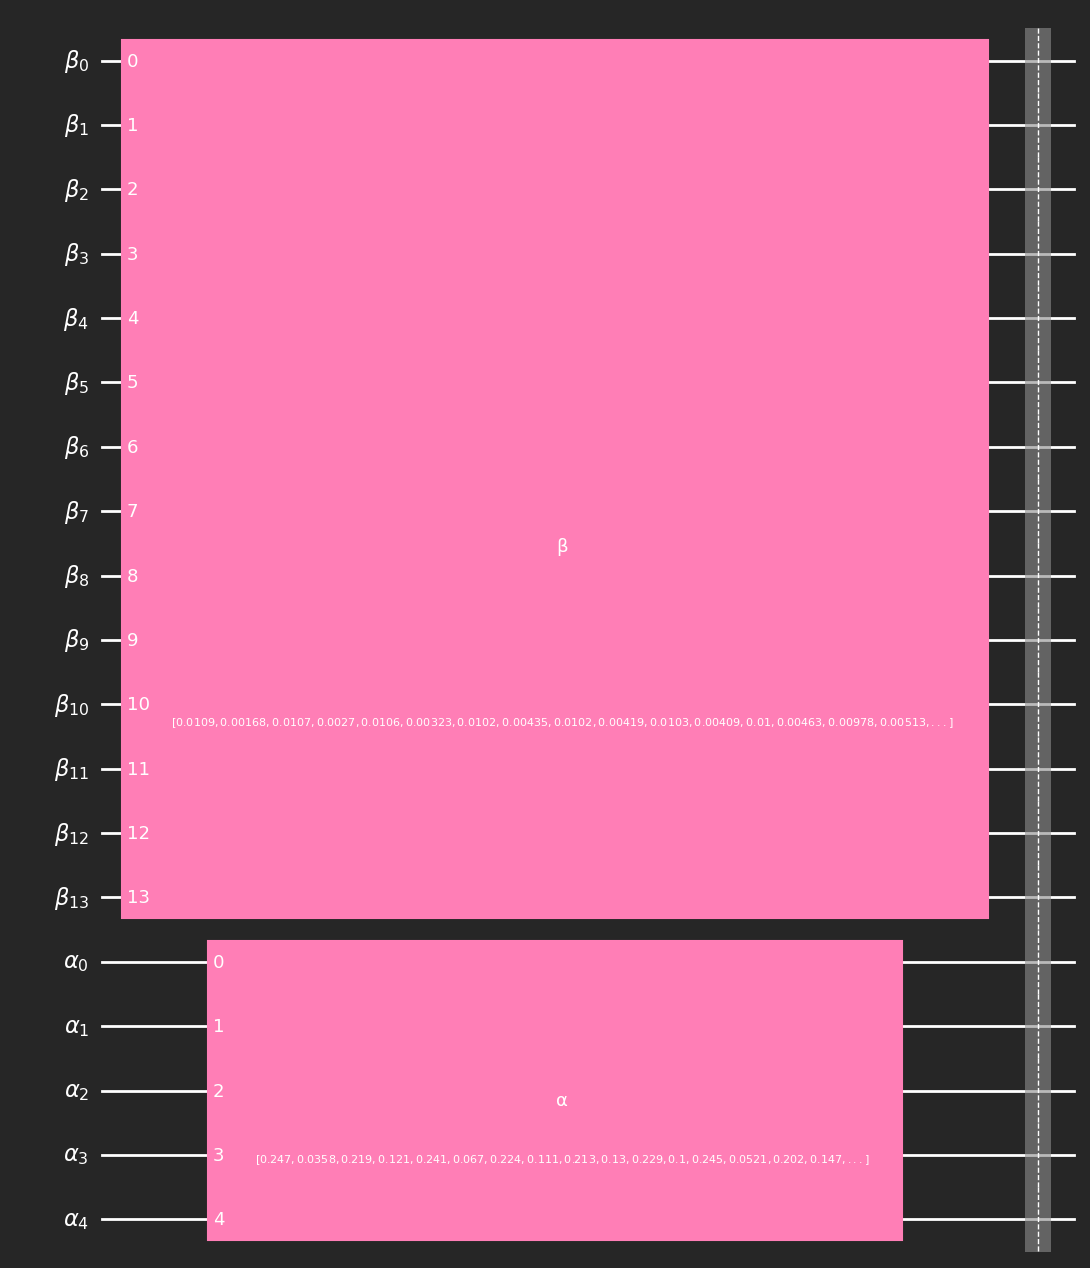

In [36]:
# --- Imports adicionais ---
from qiskit.circuit import QuantumRegister
from qiskit.circuit.library import Initialize # Precisamos importar a classe Initialize

# --- Criação e Visualização do Circuito com Rótulos Customizados ---
print("\n6. Criando circuito quântico com rótulos customizados para |α> e |β>...")

# 1. Criar os objetos de inicialização e definir seus rótulos
init_alpha = Initialize(alpha_vec)
init_alpha.label = "α"

init_beta = Initialize(beta_vec)
init_beta.label = "β"

# 2. Definir Registradores Quânticos (como antes)
alpha_reg = QuantumRegister(num_qubits_alpha, name='α') 
beta_reg = QuantumRegister(num_qubits_beta, name='β')

# 3. Criar o circuito com ambos os registradores
combined_circuit_labeled = QuantumCircuit(beta_reg, alpha_reg)

# 4. Anexar (append) as instruções de inicialização customizadas aos registradores corretos
combined_circuit_labeled.append(init_beta, beta_reg)
combined_circuit_labeled.append(init_alpha, alpha_reg)
combined_circuit_labeled.barrier()

print("Circuito combinado com rótulos customizados criado.")
print("\nDesenhando o novo circuito...")

# 5. Visualizar o Circuito
combined_circuit_labeled.draw(output='mpl')

7. Construindo o circuito do SWAP Test para calcular a distância...
Circuito do SWAP Test construído com sucesso.


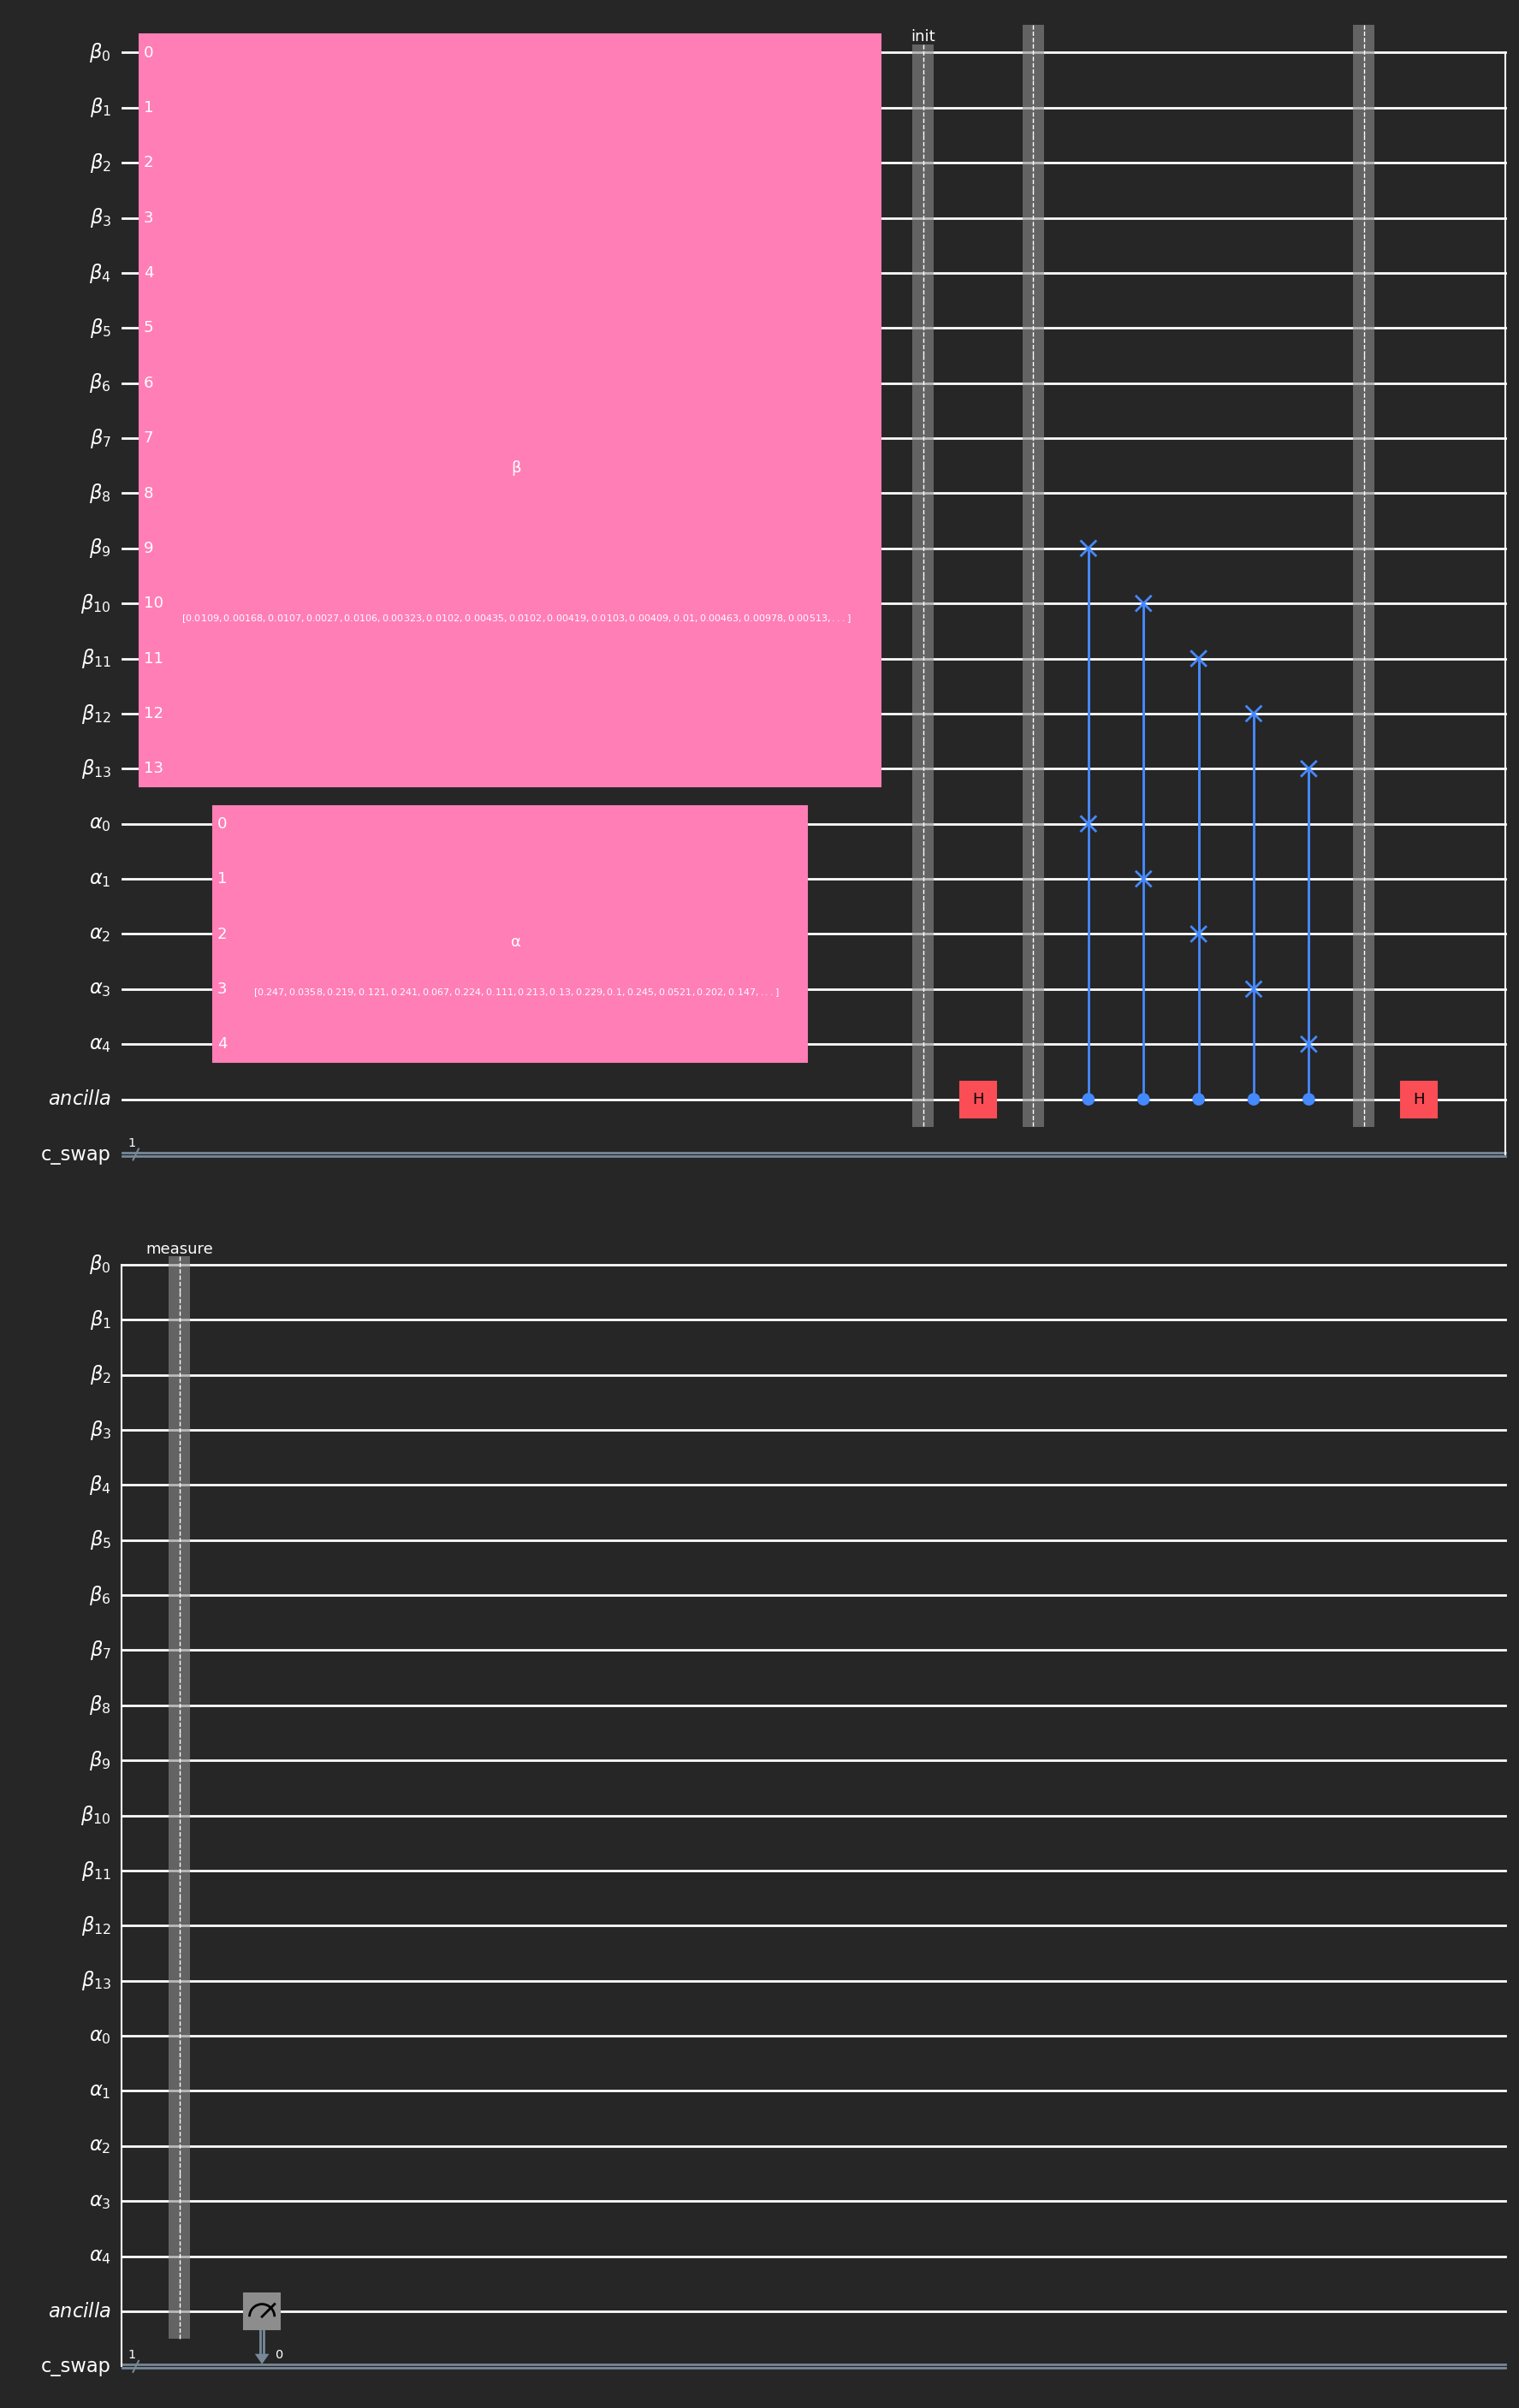

In [39]:
# --- Construção do Circuito SWAP Test ---
print("7. Construindo o circuito do SWAP Test para calcular a distância...")

# 1. Definir Registradores Quânticos com os nomes que você sugeriu
alpha_reg = QuantumRegister(num_qubits_alpha, name='α') 
beta_reg = QuantumRegister(num_qubits_beta, name='β')
ancilla_reg = QuantumRegister(1, name='ancilla')
c_reg = ClassicalRegister(1, name='c_swap')

# 2. Criar o circuito principal com todos os registradores
# Total de qubits = 14 (beta) + 5 (alpha) + 1 (ancilla) = 20
qc_swap = QuantumCircuit(beta_reg, alpha_reg, ancilla_reg, c_reg)

# 3. Anexar as instruções de inicialização customizadas
qc_swap.append(init_beta, beta_reg)
qc_swap.append(init_alpha, alpha_reg)
qc_swap.barrier(label="init")

# 4. Implementar o SWAP Test
# Colocar o qubit ancilla em superposição
qc_swap.h(ancilla_reg)
qc_swap.barrier()

# Aplicar a porta C-SWAP (Fredkin) nos qubits de característica
# O sub-registrador de característica de |α> tem n+1 qubits
# O sub-registrador de característica de |β> começa no índice m e também tem n+1 qubits
num_feature_qubits = n + 1
for k in range(num_feature_qubits):
    # O k-ésimo qubit do registrador alpha (que é todo de característica)
    alpha_qubit_k = alpha_reg[k]
    
    # O k-ésimo qubit da PARTE de característica do registrador beta
    beta_feature_qubit = beta_reg[m + k]
    
    # Aplica o C-SWAP controlado pela ancilla
    qc_swap.cswap(ancilla_reg, alpha_qubit_k, beta_feature_qubit)

qc_swap.barrier()
# Aplicar a porta Hadamard novamente na ancilla
qc_swap.h(ancilla_reg)
qc_swap.barrier(label="measure")

# 5. Medir o qubit ancilla
qc_swap.measure(ancilla_reg, c_reg)

print("Circuito do SWAP Test construído com sucesso.")

# 6. Visualizar o circuito final
qc_swap.draw(output='mpl')

8. Simulando o circuito e obtendo os resultados...
Resultado da contagem (2048 shots): {'1': 185, '0': 1863}
Probabilidade de medir o estado |1> no qubit ancilla: P(1) = 0.0903


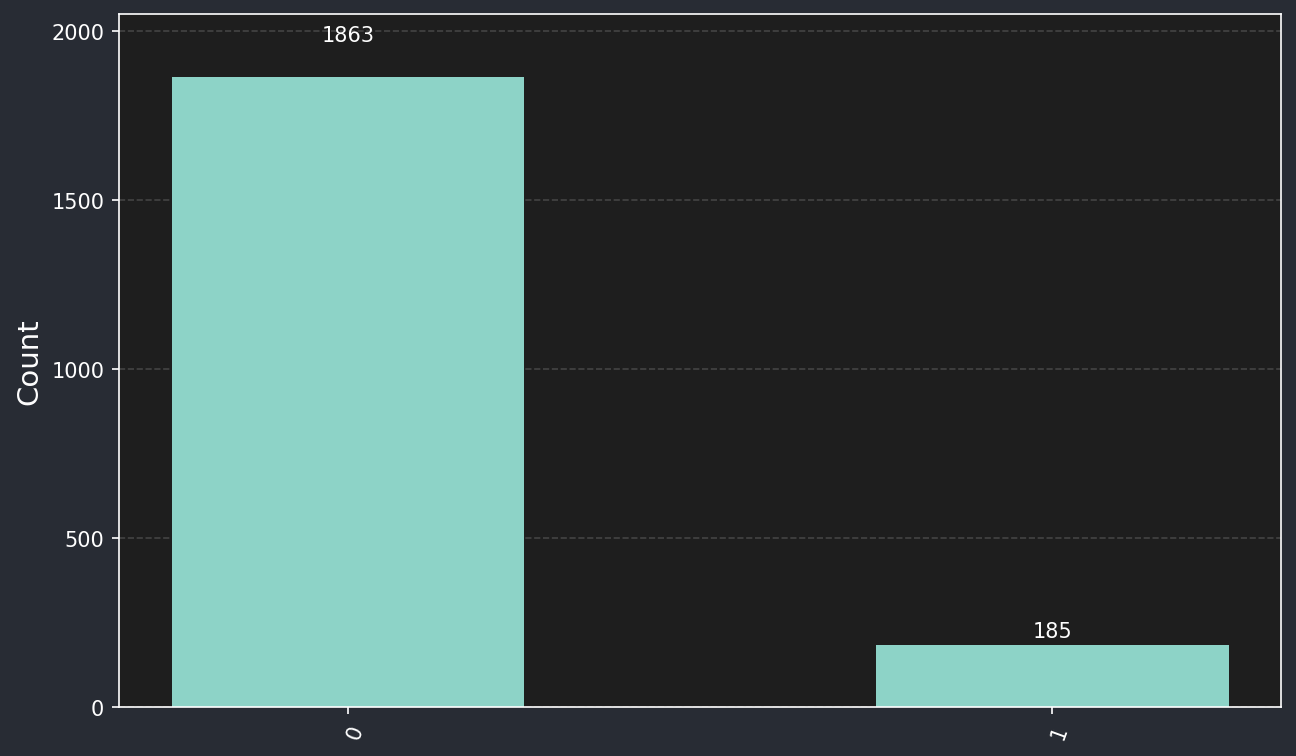

In [48]:
print("8. Simulando o circuito e obtendo os resultados...")

# Definir o número de "shots" (repetições do experimento)
# Um número maior nos dá uma estatística mais precisa
shots = 2048

# Criar o simulador
simulator = AerSimulator()

# Executar o circuito
job = simulator.run(qc_swap, shots=shots)
result = job.result()
counts = result.get_counts()

print(f"Resultado da contagem ({shots} shots): {counts}")

# Calcular a probabilidade de medir '1'
prob_1 = counts.get('1', 0) / shots
print(f"Probabilidade de medir o estado |1> no qubit ancilla: P(1) = {prob_1:.4f}")

# Plotar o histograma dos resultados
plot_histogram(counts)

In [53]:
# --- Verificação Clássica (Versão Robusta) ---
print("9. Calculando o resultado equivalente clássico de forma robusta...")

classical_probabilities = []

# Loop sobre cada um dos M vetores de treino
for j in range(M):
    v_j = v_train[j]
    
    # --- Passo de segurança: Forçar os valores para o intervalo [0, 1] ---
    # Isso evita erros de raiz quadrada com números negativos.
    v0_clipped = np.clip(v0, 0, 1)
    v_j_clipped = np.clip(v_j, 0, 1)
    
    # --- Calcula o produto interno usando os vetores "aparados" (clipped) ---
    term1 = np.dot(np.sqrt(1 - v0_clipped**2), np.sqrt(1 - v_j_clipped**2))
    term2 = np.dot(v0, v_j) # Para o dot product, podemos usar os originais
    
    inner_product = (term1 + term2) / N
    
    # --- Calcula a probabilidade P(1) para esta comparação ---
    squared_ip = np.abs(inner_product)**2
    p_j = 0.5 * (1 - squared_ip)
    
    classical_probabilities.append(p_j)

# Calcula a média de todas as probabilidades
avg_classical_prob = np.mean(classical_probabilities)

print("Cálculo clássico concluído.")

# --- Comparação dos Resultados ---
# Da sua simulação anterior (Célula 9)
counts_q = {'0': 1863, '1': 185}
shots_q = sum(counts_q.values())
prob_1_q = counts_q.get('1', 0) / shots_q

print("\n--- COMPARAÇÃO DE VALIDADE ---")
print(f"Resultado da Simulação Quântica: P(1) = {prob_1_q:.6f}")
print(f"Resultado do Cálculo Clássico:   P(1) = {avg_classical_prob:.6f}")

difference = np.abs(prob_1_q - avg_classical_prob)
print(f"\nDiferença Absoluta: {difference*100:.6f}%")

if difference < 0.01: # A diferença deve ser muito pequena
    print("\n✅ VÁLIDO: O resultado da simulação quântica é consistente com o cálculo clássico!")
else:
    print("\n⚠️ ATENÇÃO: A diferença é maior que o esperado.")

9. Calculando o resultado equivalente clássico de forma robusta...
Cálculo clássico concluído.

--- COMPARAÇÃO DE VALIDADE ---
Resultado da Simulação Quântica: P(1) = 0.090332
Resultado do Cálculo Clássico:   P(1) = 0.020056

Diferença Absoluta: 7.027592%

⚠️ ATENÇÃO: A diferença é maior que o esperado.


In [59]:
# --- Imports adicionais ---
import random
from tqdm import tqdm # Para uma barra de progresso visual

print("12. Simulando o algoritmo de Dürr para encontrar os k-vizinhos...")

# --- Parâmetros ---
k = 5 # O número de vizinhos que queremos encontrar
num_iteracoes = int(np.sqrt(k * M)) # O(sqrt(kM)) iterações

# --- 1. Decodificar o estado |σ> para uma lista clássica ---
# Cada entrada não-nula em sigma_vec corresponde a um estado |j, d_j>
database = []
non_zero_indices = np.where(sigma_vec != 0)[0]
for idx in non_zero_indices:
    # O índice 'j' da imagem é o quociente da divisão por dim_dist
    j = idx // dim_dist
    # A distância 'd_j' é o resto
    d_j = idx % dim_dist
    database.append({'index': j, 'distance': d_j})

print(f"Estado |σ> decodificado. Temos {len(database)} entradas para buscar.")

# --- 2. Inicializar o conjunto K de k candidatos ---
random.seed(42)
# Pega k índices aleatórios do nosso banco de dados
initial_indices = random.sample(range(len(database)), k)
K_candidates = [database[i] for i in initial_indices]

print(f"Inicializando com k={k} candidatos aleatórios.")
print(f"Número de iterações da busca: {num_iteracoes}")

# --- 3. Loop principal de busca e atualização ---
for _ in tqdm(range(num_iteracoes), desc="Buscando vizinhos"):
    # Encontrar o candidato em K com a maior distância
    worst_candidate = max(K_candidates, key=lambda x: x['distance'])
    d_max = worst_candidate['distance']
    
    # Simular a busca de Grover: encontrar todos os vizinhos melhores que o pior candidato
    better_neighbors = [
        item for item in database 
        if item['distance'] < d_max and item not in K_candidates
    ]
    
    # Se encontrarmos vizinhos melhores...
    if better_neighbors:
        # Escolhe um deles aleatoriamente (simulando o resultado de uma busca)
        new_neighbor = random.choice(better_neighbors)
        
        # Substitui o pior candidato pelo novo vizinho encontrado
        K_candidates.remove(worst_candidate)
        K_candidates.append(new_neighbor)

# --- 4. Resultado Final ---
# Ordenar os resultados finais pela distância para melhor visualização
K_final = sorted(K_candidates, key=lambda x: x['distance'])

print("\nBusca concluída! Os k-vizinhos mais próximos encontrados são:")
for neighbor in K_final:
    print(f"  Índice da Imagem de Treino: {neighbor['index']}, Distância Digitalizada: {neighbor['distance']}")

# Guardar apenas os índices para o próximo passo
k_final_indices = [neighbor['index'] for neighbor in K_final]

12. Simulando o algoritmo de Dürr para encontrar os k-vizinhos...


NameError: name 'sigma_vec' is not defined

In [60]:
# --- Simulação Clássica do Estado |σ> ---
print("\n11. Construindo o vetor de estado para |σ> para o próximo passo...")

# Precisamos das probabilidades individuais calculadas na Célula 10
# A variável 'classical_probabilities' contém P(1) para cada j.

# Definir a precisão do nosso registrador de distância
q_dist_qubits = 7  # 7 qubits nos dão uma precisão de 1/128
dim_dist = 2**q_dist_qubits

# O estado |σ> armazena o índice da imagem 'j' e a distância 'd_j'
num_qubits_sigma = m + q_dist_qubits # 9 + 7 = 16 qubits
dim_sigma = 2**num_qubits_sigma

# Criar o vetor de estado para |σ>
sigma_vec = np.zeros(dim_sigma, dtype=complex)

# Loop sobre as M imagens de treino
for j in range(M):
    # Pega a probabilidade P(1) para a j-ésima imagem
    p_j = classical_probabilities[j]
    
    # Converte a probabilidade (valor analógico) em um inteiro (digital)
    # que pode ser armazenado no registrador de 'q_dist_qubits'
    dist_int = int(round(p_j * (dim_dist - 1)))
    
    # O índice no vetor de estado corresponde ao número binário |j, dist_int>
    idx = j * dim_dist + dist_int
    
    # A amplitude para este estado base é 1 (antes da normalização)
    sigma_vec[idx] = 1

# Normaliza o vetor de estado final
sigma_vec /= np.linalg.norm(sigma_vec)

print(f"Vetor de estado 'sigma_vec' (representando |σ>) construído.")
print(f"Ele tem {num_qubits_sigma} qubits e dimensão {len(sigma_vec)}.")
print("Este vetor está pronto para ser usado como entrada para o algoritmo de Dürr.")


11. Construindo o vetor de estado para |σ> para o próximo passo...
Vetor de estado 'sigma_vec' (representando |σ>) construído.
Ele tem 16 qubits e dimensão 65536.
Este vetor está pronto para ser usado como entrada para o algoritmo de Dürr.


In [61]:
# --- Imports adicionais ---
import random
from tqdm import tqdm # Para uma barra de progresso visual

print("12. Simulando o algoritmo de Dürr para encontrar os k-vizinhos...")

# --- Parâmetros ---
k = 5 # O número de vizinhos que queremos encontrar
num_iteracoes = int(np.sqrt(k * M)) # O(sqrt(kM)) iterações

# --- 1. Decodificar o estado |σ> para uma lista clássica ---
# Cada entrada não-nula em sigma_vec corresponde a um estado |j, d_j>
database = []
non_zero_indices = np.where(sigma_vec != 0)[0]
for idx in non_zero_indices:
    # O índice 'j' da imagem é o quociente da divisão por dim_dist
    j = idx // dim_dist
    # A distância 'd_j' é o resto
    d_j = idx % dim_dist
    database.append({'index': j, 'distance': d_j})

print(f"Estado |σ> decodificado. Temos {len(database)} entradas para buscar.")

# --- 2. Inicializar o conjunto K de k candidatos ---
random.seed(42)
# Pega k índices aleatórios do nosso banco de dados
initial_indices = random.sample(range(len(database)), k)
K_candidates = [database[i] for i in initial_indices]

print(f"Inicializando com k={k} candidatos aleatórios.")
print(f"Número de iterações da busca: {num_iteracoes}")

# --- 3. Loop principal de busca e atualização ---
for _ in tqdm(range(num_iteracoes), desc="Buscando vizinhos"):
    # Encontrar o candidato em K com a maior distância
    worst_candidate = max(K_candidates, key=lambda x: x['distance'])
    d_max = worst_candidate['distance']
    
    # Simular a busca de Grover: encontrar todos os vizinhos melhores que o pior candidato
    better_neighbors = [
        item for item in database 
        if item['distance'] < d_max and item not in K_candidates
    ]
    
    # Se encontrarmos vizinhos melhores...
    if better_neighbors:
        # Escolhe um deles aleatoriamente (simulando o resultado de uma busca)
        new_neighbor = random.choice(better_neighbors)
        
        # Substitui o pior candidato pelo novo vizinho encontrado
        K_candidates.remove(worst_candidate)
        K_candidates.append(new_neighbor)

# --- 4. Resultado Final ---
# Ordenar os resultados finais pela distância para melhor visualização
K_final = sorted(K_candidates, key=lambda x: x['distance'])

print("\nBusca concluída! Os k-vizinhos mais próximos encontrados são:")
for neighbor in K_final:
    print(f"  Índice da Imagem de Treino: {neighbor['index']}, Distância Digitalizada: {neighbor['distance']}")

# Guardar apenas os índices para o próximo passo
k_final_indices = [neighbor['index'] for neighbor in K_final]

12. Simulando o algoritmo de Dürr para encontrar os k-vizinhos...
Estado |σ> decodificado. Temos 512 entradas para buscar.
Inicializando com k=5 candidatos aleatórios.
Número de iterações da busca: 50


Buscando vizinhos: 100%|██████████| 50/50 [00:00<00:00, 58092.85it/s]


Busca concluída! Os k-vizinhos mais próximos encontrados são:
  Índice da Imagem de Treino: 109, Distância Digitalizada: 0
  Índice da Imagem de Treino: 507, Distância Digitalizada: 0
  Índice da Imagem de Treino: 216, Distância Digitalizada: 0
  Índice da Imagem de Treino: 263, Distância Digitalizada: 0
  Índice da Imagem de Treino: 303, Distância Digitalizada: 0


In [62]:
# --- Imports adicionais ---
from statistics import mode

print("\n13. Realizando a classificação final por votação majoritária...")

# Precisamos dos rótulos do nosso conjunto de treino (variável y_train_M da Célula 3)
# e do rótulo real da imagem de teste (variável true_label da Célula 4)

# 1. Obter os rótulos dos k vizinhos encontrados
neighbor_labels = [y_train_M[i] for i in k_final_indices]
print(f"Rótulos dos {k} vizinhos mais próximos: {neighbor_labels}")

# 2. Realizar a votação majoritária
try:
    predicted_label = mode(neighbor_labels)
except statistics.StatisticsError: # Caso de empate raro
    predicted_label = neighbor_labels[0] # Pega o primeiro como desempate

print("\n--- RESULTADO DA CLASSIFICAÇÃO ---")
print(f"O rótulo previsto para a imagem de teste é: {predicted_label}")
print(f"O rótulo verdadeiro da imagem de teste era: {true_label}")

if predicted_label == true_label:
    print("\n✅ SUCESSO: A classificação do algoritmo QkNN está CORRETA!")
else:
    print("\n❌ FALHA: A classificação do algoritmo QkNN está INCORRETA.")


13. Realizando a classificação final por votação majoritária...
Rótulos dos 5 vizinhos mais próximos: [7, 7, 7, 7, 7]

--- RESULTADO DA CLASSIFICAÇÃO ---
O rótulo previsto para a imagem de teste é: 7
O rótulo verdadeiro da imagem de teste era: 7

✅ SUCESSO: A classificação do algoritmo QkNN está CORRETA!


In [64]:
# --- Função de Simulação QkNN ---
def run_qknn_simulation(test_idx, X_train_M, y_train_M, X_test_set, y_test_set, k=5, M=512, N=16):
    """
    Executa uma simulação completa do QkNN para um único índice de teste.
    Retorna um dicionário com os resultados.
    """
    # 1. Preparação da Imagem de Teste
    X_test_image_pixels = X_test_set[test_idx]
    true_label = y_test_set[test_idx]
    
    # 2. Pré-processamento (usando os scalers já ajustados)
    v0 = pca.transform(scaler.transform(X_test_image_pixels.reshape(1, -1)))
    v0 = min_max_scaler.transform(v0).flatten()
    
    # 3. Simulação do SWAP Test (Cálculo Clássico das Distâncias)
    classical_probabilities = []
    for j in range(M):
        v_j = v_train[j]
        v0_clipped = np.clip(v0, 0, 1)
        v_j_clipped = np.clip(v_j, 0, 1)
        term1 = np.dot(np.sqrt(1 - v0_clipped**2), np.sqrt(1 - v_j_clipped**2))
        term2 = np.dot(v0, v_j)
        inner_product = (term1 + term2) / N
        squared_ip = np.abs(inner_product)**2
        p_j = 0.5 * (1 - squared_ip)
        classical_probabilities.append(p_j)

    # 4. Simulação da Estimativa de Amplitude
    q_dist_qubits = 7
    dim_dist = 2**q_dist_qubits
    database = []
    for j in range(M):
        p_j = classical_probabilities[j]
        dist_int = int(round(p_j * (dim_dist - 1)))
        database.append({'index': j, 'distance': dist_int})

    # 5. Simulação do Algoritmo de Dürr
    num_iteracoes = int(np.sqrt(k * M))
    initial_indices = random.sample(range(len(database)), k)
    K_candidates = [database[i] for i in initial_indices]
    
    for _ in range(num_iteracoes):
        worst_candidate = max(K_candidates, key=lambda x: x['distance'])
        d_max = worst_candidate['distance']
        better_neighbors = [item for item in database if item['distance'] < d_max and item not in K_candidates]
        if better_neighbors:
            new_neighbor = random.choice(better_neighbors)
            K_candidates.remove(worst_candidate)
            K_candidates.append(new_neighbor)
            
    k_final_indices = [neighbor['index'] for neighbor in K_candidates]

    # 6. Votação Majoritária
    neighbor_labels = [y_train_M[i] for i in k_final_indices]
    try:
        predicted_label = mode(neighbor_labels)
    except:
        predicted_label = neighbor_labels[0] # Desempate

    # 7. Retornar Resultados
    return {
        "Test Index": test_idx,
        "True Label": true_label,
        "Predicted Label": predicted_label,
        "Correct?": true_label == predicted_label,
        "Neighbor Indices": k_final_indices,
        "Neighbor Labels": neighbor_labels,
        "Avg P(1)": np.mean(classical_probabilities)
    }

print("Função 'run_qknn_simulation' definida com sucesso.")

Função 'run_qknn_simulation' definida com sucesso.


In [72]:
# --- Loop Principal do Experimento ---
num_runs = 10000
results_list = []

# Selecionar 50 índices aleatórios e únicos do conjunto de teste
test_indices = random.sample(range(len(X_test_set)), num_runs)

print(f"Iniciando simulação para {num_runs} imagens de teste...")

# Usamos v_train (pré-processado) e y_train_M (rótulos originais)
for test_idx in tqdm(test_indices, desc="Executando Simulações"):
    result = run_qknn_simulation(test_idx, X_train_M, y_train_M, X_test_set, y_test_set, k=k, M=M, N=N)
    results_list.append(result)

print("Simulações concluídas!")

Iniciando simulação para 10000 imagens de teste...


Executando Simulações: 100%|██████████| 10000/10000 [01:05<00:00, 152.35it/s]

Simulações concluídas!


In [74]:
# --- Análise dos Resultados em Tabela ---

# Criar um DataFrame com os resultados
results_df = pd.DataFrame(results_list)

# Calcular a acurácia geral
accuracy = results_df['Correct?'].sum() / num_runs * 100

print(f"\n--- ACURÁCIA GERAL ({num_runs} testes) ---")
print(f"Acurácia do QkNN Simulado: {accuracy:.2f}%")

print("\n--- Amostra dos Resultados ---")
# Exibir as 10 primeiras linhas da tabela de resultados
display(results_df)


--- ACURÁCIA GERAL (10000 testes) ---
Acurácia do QkNN Simulado: 64.56%

--- Amostra dos Resultados ---


,Test Index,True Label,Predicted Label,Correct?,Neighbor Indices,Neighbor Labels,Avg P(1)
0,3340,8,3,False,"[321, 205, 34, 96, 300]","[3, 8, 5, 8, 3]",0.013467
1,6723,1,1,True,"[297, 118, 454, 350, 55]","[5, 1, 1, 1, 1]",0.013091
2,8221,5,2,False,"[64, 26, 129, 67, 273]","[8, 2, 5, 5, 2]",0.020714
3,7726,4,3,False,"[312, 315, 487, 444, 200]","[3, 9, 8, 1, 4]",0.013171
4,1020,0,8,False,"[487, 83, 246, 105, 435]","[8, 0, 6, 4, 1]",0.012154
...,...,...,...,...,...,...,...
9995,4238,0,0,True,"[413, 310, 27, 83, 117]","[8, 6, 0, 0, 0]",0.015690
9996,5691,5,5,True,"[43, 306, 489, 271, 263]","[5, 5, 9, 7, 7]",0.017898
9997,7960,6,6,True,"[180, 243, 324, 485, 70]","[6, 6, 6, 6, 6]",0.015458
9998,9474,3,3,True,"[282, 32, 162, 261, 479]","[3, 3, 3, 3, 3]",0.021885



--- ANÁLISE VISUAL ---


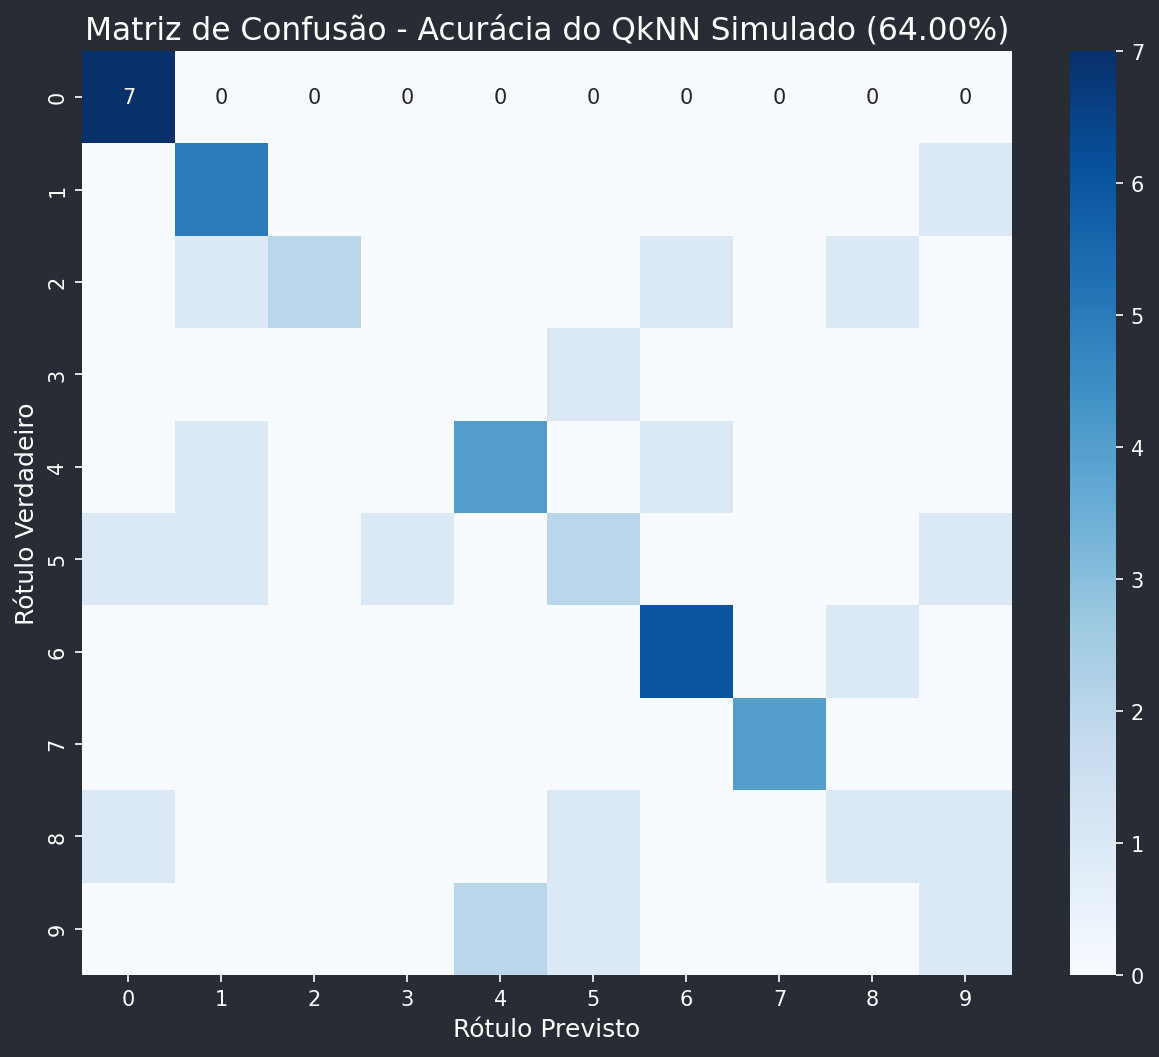

In [68]:
# --- Imports para o Gráfico ---
import seaborn as sns
from sklearn.metrics import confusion_matrix

print("\n--- ANÁLISE VISUAL ---")

# Extrair os rótulos verdadeiros e previstos do DataFrame
true_labels = results_df['True Label']
predicted_labels = results_df['Predicted Label']

# Criar a matriz de confusão
cm = confusion_matrix(true_labels, predicted_labels, labels=range(10))

# Criar a figura para o gráfico
plt.figure(figsize=(10, 8))

# Desenhar o heatmap (mapa de calor)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))

plt.title(f'Matriz de Confusão - Acurácia do QkNN Simulado ({accuracy:.2f}%)', fontsize=15)
plt.ylabel('Rótulo Verdadeiro', fontsize=12)
plt.xlabel('Rótulo Previsto', fontsize=12)
plt.show()